<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex00_%EB%94%A5%EB%9F%AC%EB%8B%9D_%EB%A7%9B%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 딥러닝
- 인간의 신경망을 모방하여 학습하고 예측하는 기술
- 대량의 데이터에서 복잡한 패턴, 규칙을 찾아내는 능력이 뛰어남
- 머신러닝보다 유연한 사고를 하는 방식
- 주로 자연어처리(인간의 언어를 다루는 영역), 영상, 이미지 분야, 음성등 다양한 분야에서 활용되고 있는 기술
- 인간의 뉴런 -> 딥러닝 선형모델

### 머신러닝 vs 딥러닝
- 머신러닝
  - 모델을 불러오는 작업(완성된 객체) -> 모델 학습 -> 모델 예측 -> 모델 평가
  - 완제품로봇 -> 팔이나 다리를 움직이는 정도로 가능
- 딥러닝
  - 모델을 불러오는 작업(모델을 직접 구성) -> 모델 학습
  -> 모델 예측 -> 모델 평가
  - 부품을 통해 로봇을 조립 -> 우리가 원하는 모양을 가진 로봇을 만들 수 있음
  

In [ ]:
%cd /content/drive/MyDrive/딥러닝

/content/drive/MyDrive/딥러닝


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('./data/student-mat.csv', delimiter=';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
#데이터 정보 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### 데이터 분리
- X,y데이터 분리 ( 문제데이터 / 정답데이터 )
- train, test 분리

In [ ]:
X = data[['studytime', 'freetime']]
y = data['G3']

In [ ]:
# 데이터 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

In [ ]:
# 크기확인
print('훈련용 문제 데이터 : ', X_train.shape)
print('훈련용 정답 데이터 : ', y_train.shape)
print('테스트용 문제 데이터 : ', X_test.shape)
print('테스트용 정답 데이터 : ', y_test.shape)

훈련용 문제 데이터 :  (276, 2)
훈련용 정답 데이터 :  (276,)
테스트용 문제 데이터 :  (119, 2)
테스트용 정답 데이터 :  (119,)


In [ ]:
y_train

,G3
304,13
198,18
26,11
153,0
318,10
...,...
73,14
118,8
189,10
206,7


### 머신러닝 모델링
- 성적을 예측할 모델을 사용하기 때문에 회귀 모델을 사용

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error # 회귀모델의 MSE 확인 도구

# 모델 객체 생성
linear_model = LinearRegression()

# 모델 학습
linear_model.fit(X_train, y_train)

# 모델 평가
linear_model.score(X_train, y_train)

0.014443243476712553

In [ ]:
# 모델 예측
pre = linear_model.predict(X_test)

# MSE 확인
mean_squared_error(y_test, pre)

21.72675646101634


# 딥러닝 모델 사용

### TensorFlow 사용
- 신경망 구조 설계
- 학습 방법 설정
- 학습
- 예측, 평가

In [ ]:
# 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer

# Sequential -> 뼈대를 만드는데 도음을 주는 도구 : 층을 순차적으로 쌓아 올리는 모델 구조를 지원
# Dense(완전연결층) : 모든 입력 뉴런이 모든 출력뉴런과 연결된 구조를 가질 수 있도록 도와주는 도구 ( 중간층 , 출력층)
# InpuyLayer : 입력층을 쌓을 수 있도록 도와주는 도구
# activation (활성화 함수) : 뉴런이 입력신호를 받아 다음 뉴런으로 전달할 수 있도록 일종의 스위치 역할을 진행

In [ ]:
# 신경망 구조 설계
model = Sequential()
# 입력층 쌓기
model.add(InputLayer(input_shape=(2,))) # 입력 특성의 개수
# 은닉(중간)층 쌓기 - 학습의 성능과 연관이 있는 층
model.add(Dense(units=10, activation='sigmoid'))
# units -> 뉴런의 개수 -> 많을 수록 학습 능력이 올라갈 가능성이 높음
# activation(활성화 함수) : 사람처럼 생각할 수 있도록 도와주는 기능 중 하나
# 출력층 -> 출력받고자 하는 데이터의 형태를 지정(회귀)
model.add(Dense(units=1, activation='linear'))
# 출력층에서 회귀의 경우는 activation을 linear로 설정
# 분류의 경우에는 상황에 따라 sigmoid / softmax 등을 사용
# 출력층 정리
# 회귀 : linear
# 이진분류 : sigmoid
# 다중분류 : softmax (확률계산을 통해 어떤 클래스인지를 판단하는 방법)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# 학습 방법 및 평가방법 설정
model.compile(
    loss = 'mean_squared_error',
    optimizer = 'SGD',
    metrics = ['mse']
)
# loss : 오차를 의미 -> 모델이 잘 예측을 했는지 못했는지를 평가하는 지표
# optimizer (최적화함수) : 모델의 성능을 높이는 방법 (오차를 줄이는 방법) -> 경사하강법
# metrics : 평가 지표

In [ ]:
# 학습 진행
 #epochs -> 학습횟수
h = model.fit(X_train, y_train, validation_split = 0.2, epochs = 20)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 107.6850 - mse: 107.6850 - val_loss: 52.4842 - val_mse: 52.4842
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 38.0505 - mse: 38.0505 - val_loss: 26.1216 - val_mse: 26.1216
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 23.4652 - mse: 23.4652 - val_loss: 21.9631 - val_mse: 21.9631
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.9436 - mse: 20.9436 - val_loss: 20.9298 - val_mse: 20.9298
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 18.2650 - mse: 18.2650 - val_loss: 21.1215 - val_mse: 21.1215
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 20.2919 - mse: 20.2919 - val_loss: 21.1563 - val_mse: 21.1563
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 18.6530 - mse: 18.6530 - val_loss: 21.2673 - val_mse: 21.2673
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.5762 - mse: 19.5762 - val_loss: 21.3297 - val_mse: 21.3297
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/st

In [ ]:
# score와 비슷한 기능을 가진 함수
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.2506 - mse: 22.2506


[21.5134220123291, 21.5134220123291]

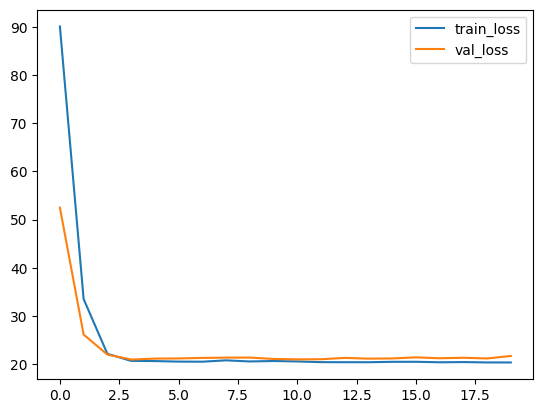

In [ ]:
# 학습결과 시각화
plt.plot(h.history['loss'], label='train_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()